**Customer Churn Prediction**

**Import Libraries**

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load Dataset**

In [116]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

**Exploratory Data Analysis (EDA)**

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- Dataset has 7043 rows and 21 columns
- Shows data types and missing values


In [118]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**- Shows statistical summary like mean, min, max**

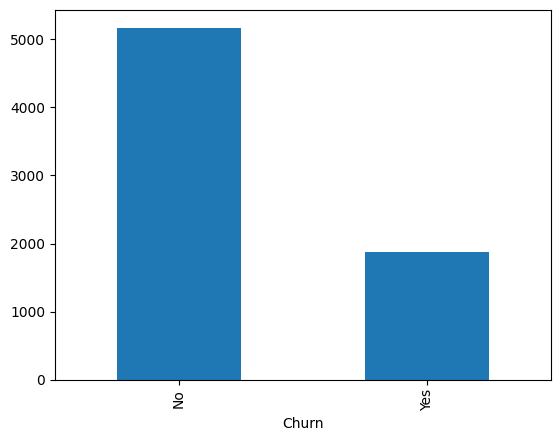

In [119]:
df["Churn"].value_counts().plot(kind="bar")
plt.show()

- Most customers did not churn

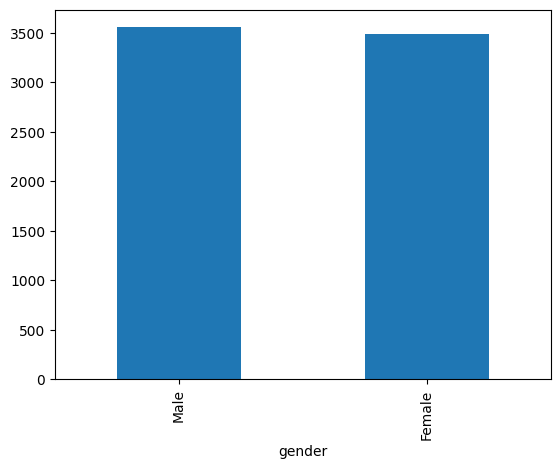

In [120]:
df["gender"].value_counts().plot(kind="bar")
plt.show()

**- Gender distribution is balanced**

<Axes: >

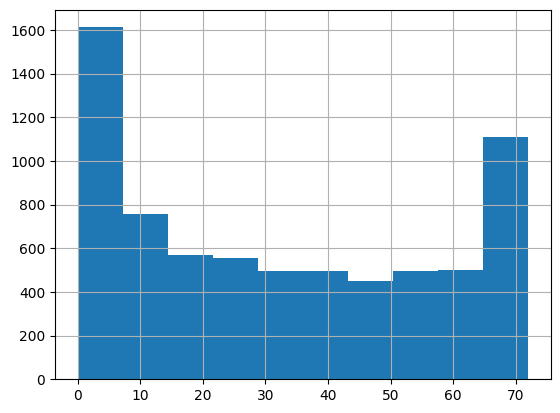

In [121]:
df["tenure"].hist()

- Most customers have low tenure


**Data Cleaning**

In [122]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df = df.drop('customerID', axis=1)

- Converted TotalCharges to numeric
- Removed missing values


**SPLIT X and y**

In [123]:
X = df.drop('Churn', axis=1)
y = df['Churn']

**Feature Engineering**

In [124]:
X = pd.get_dummies(X, drop_first=True)
y = y.map({'Yes': 1, 'No': 0})

explaination:--
- Converted categorical columns to numerical using get_dummies
- Converted target variable (Churn) to 0 and 1

**Train-Test Split**

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# random_state=42
# 🎯 THINK LIKE THIS

# You have 100 students (data)

# You want:

# 80 for training
# 20 for testing
# ❓ WITHOUT random_state

# Every time you run:

# 👉 Different 20 students go to test set

# So:

# Run 1 → accuracy = 80%
# Run 2 → accuracy = 75%
# Run 3 → accuracy = 82%

# 😵 You get confused

# ✅ WITH random_state=42

# 👉 Same 20 students are chosen EVERY TIME

# So:

# Run 1 → 80%
# Run 2 → 80%
# Run 3 → 80%

# ✅ Stable result

**Train Model**

In [126]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
## the error is because of iterations , u can ignore this at begineer level

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

**Prediction**

In [127]:
y_pred = model.predict(X_test)


- Model predicts churn on test data

**Evaluation//Check Accuracy**

In [128]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7874911158493249


**- Model achieved around 78% accuracy**

**Conclusion**
- Model predicts customer churn with ~78% accuracy
- Features like tenure and monthly charges influence churn
- Model can help companies reduce customer loss
